# 01 Model Setup and Sampling

This notebook builds the simulated imaging field before any stimulus responses are computed. The purpose is to check that the sampled population is scientifically plausible enough for a null model: local retinotopy should be smooth, RF centers should scatter around that map, PO values should be roughly uniform, and RF size/SF distributions should match the assumptions in the config.

Cortical coordinates are in microns. Visual coordinates are in degrees. The notebook uses debug settings for speed, but the same code path is used by the full simulation.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.utils import load_config, rng_from_config
from src.sampling import sample_population
from src.coordinate_mapping import mapping_error_field
from src.rf_models import gabor_kernel
from src.plotting import set_plot_style

set_plot_style()
fig_dir = ROOT / 'results/figures'
fig_dir.mkdir(parents=True, exist_ok=True)

cfg = load_config(ROOT / 'configs/default.yaml', debug=True)
rng = rng_from_config(cfg)
pop = sample_population(cfg, rng)
display(pop.head())
print(f"n_neurons={len(pop)}, FOV={cfg['cortical_field']['size_um']} um")

,neuron_id,x_um,y_um,theta0_deg,f0_cpd,sigma_x_deg,sigma_y_deg,phase_rad,gain,baseline,gamma,azimuth_deg,elevation_deg,retino_jitter_az_deg,retino_jitter_el_deg
0,0,386.978024,219.439220,42.778505,0.089941,3.509902,1.480351,3.535375,0.948995,0.05,1.25,3.374663,2.678475,0.873983,2.598467
1,1,429.298960,348.684015,153.500603,0.055347,2.795053,0.988101,4.747195,1.102558,0.05,1.25,4.635727,2.377666,1.766118,0.658630
2,2,47.088674,487.811176,62.645656,0.063065,2.378778,1.548900,1.617432,1.419488,0.05,1.25,-1.648900,2.781131,2.615902,0.658490
3,3,380.569851,393.032153,153.602041,0.056354,2.827723,0.926270,5.194874,1.046372,0.05,1.25,3.124548,1.635381,1.241982,-0.444856
4,4,64.056816,225.192969,53.809857,0.049192,1.249649,1.065788,5.827685,0.796235,0.05,1.25,-3.101812,-1.926383,0.099819,-1.046136


n_neurons=160, FOV=500.0 um


## Sampled Parameter Checks

The first sanity check is distributional. PO should be approximately uniform. Preferred SFs are low-biased, RF envelopes are broad on the scale of 1 degree, and retinotopic jitter is centered near zero. These are config assumptions, not hard-coded biological claims.

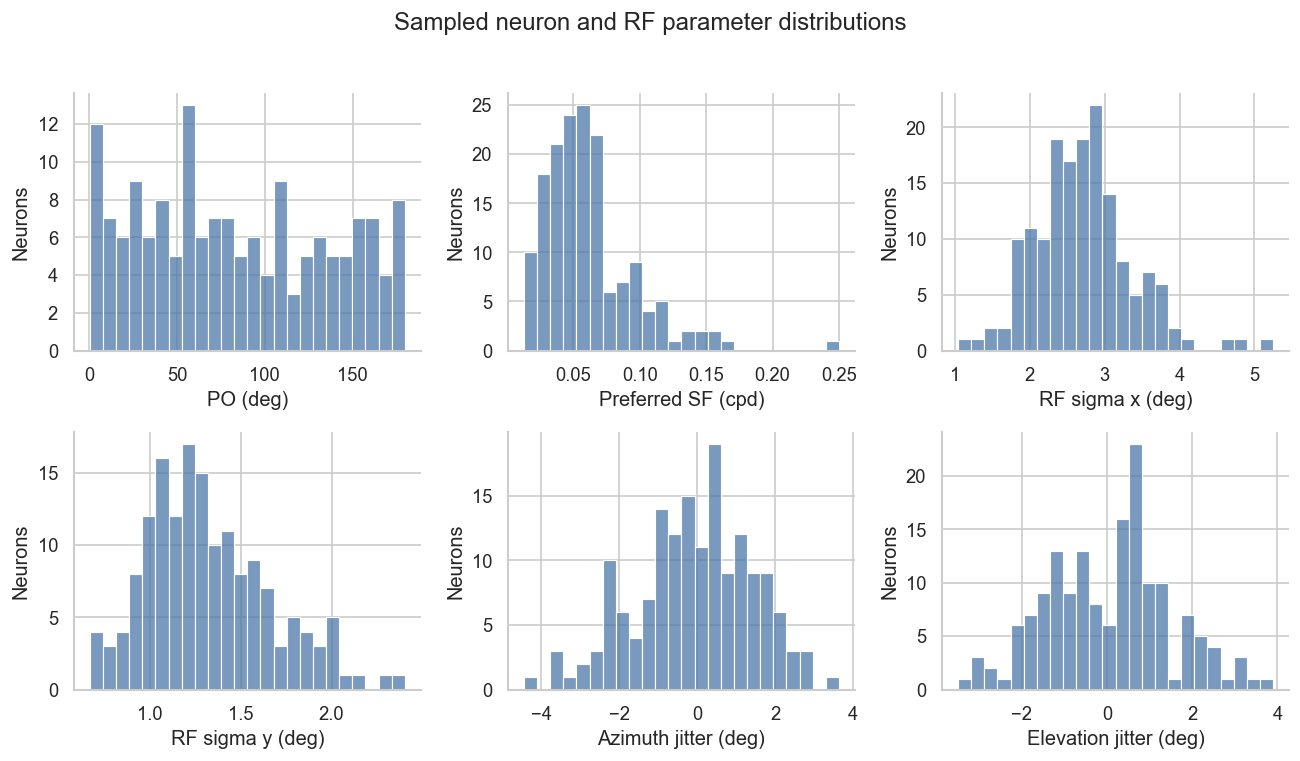

In [2]:
fields = [
    ('theta0_deg', 'PO (deg)'),
    ('f0_cpd', 'Preferred SF (cpd)'),
    ('sigma_x_deg', 'RF sigma x (deg)'),
    ('sigma_y_deg', 'RF sigma y (deg)'),
    ('retino_jitter_az_deg', 'Azimuth jitter (deg)'),
    ('retino_jitter_el_deg', 'Elevation jitter (deg)'),
]
fig, axes = plt.subplots(2, 3, figsize=(11, 6.2))
for ax, (field, label) in zip(axes.ravel(), fields):
    sns.histplot(pop[field], bins=24, ax=ax, color='#4C78A8')
    ax.set_xlabel(label)
    ax.set_ylabel('Neurons')
fig.suptitle('Sampled neuron and RF parameter distributions', y=1.02)
plt.tight_layout()
plt.savefig(fig_dir / 'notebook01_parameter_distributions.png', bbox_inches='tight')

## Local Retinotopy

The local map is linear across the 500 x 500 um field, then each cell receives Gaussian retinotopic scatter. This is meant to capture a smooth local field with cell-to-cell deviations, not a full visual-area map.

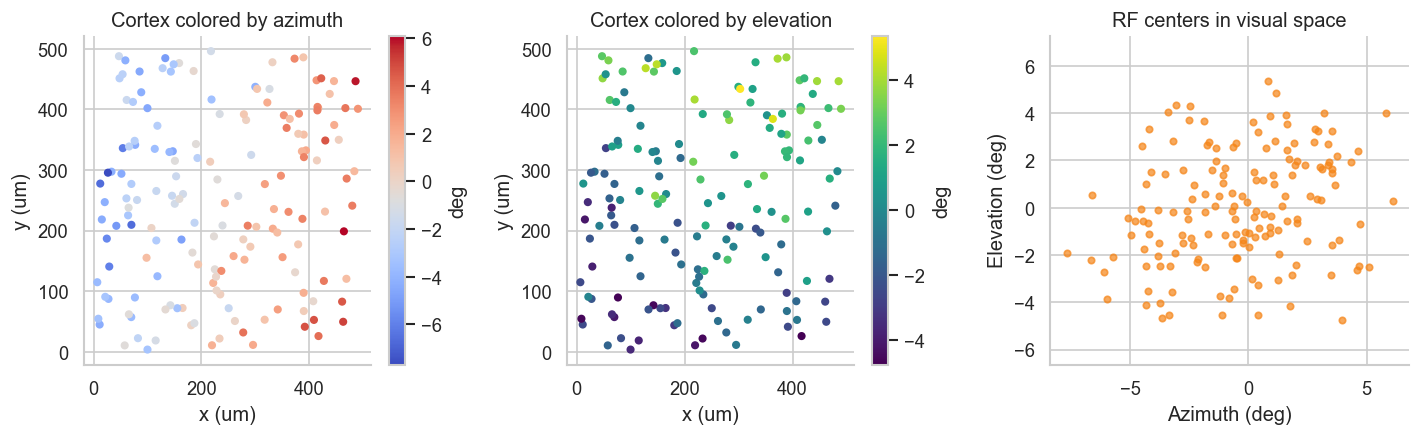

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
sc0 = axes[0].scatter(pop.x_um, pop.y_um, c=pop.azimuth_deg, s=15, cmap='coolwarm')
axes[0].set_title('Cortex colored by azimuth')
axes[0].set_xlabel('x (um)'); axes[0].set_ylabel('y (um)')
plt.colorbar(sc0, ax=axes[0], label='deg')
sc1 = axes[1].scatter(pop.x_um, pop.y_um, c=pop.elevation_deg, s=15, cmap='viridis')
axes[1].set_title('Cortex colored by elevation')
axes[1].set_xlabel('x (um)'); axes[1].set_ylabel('y (um)')
plt.colorbar(sc1, ax=axes[1], label='deg')
axes[2].scatter(pop.azimuth_deg, pop.elevation_deg, s=15, alpha=0.7, color='#F58518')
axes[2].set_title('RF centers in visual space')
axes[2].set_xlabel('Azimuth (deg)'); axes[2].set_ylabel('Elevation (deg)')
axes[2].axis('equal')
plt.tight_layout()
plt.savefig(fig_dir / 'notebook01_retinotopy.png', bbox_inches='tight')

## Mapping Sanity Check

The project has exact and approximate coordinate pipelines. The approximate versions intentionally add scale, origin, rotation, anisotropy, and nonlinear errors so we can separate true gaze geometry from analysis/mapping error.

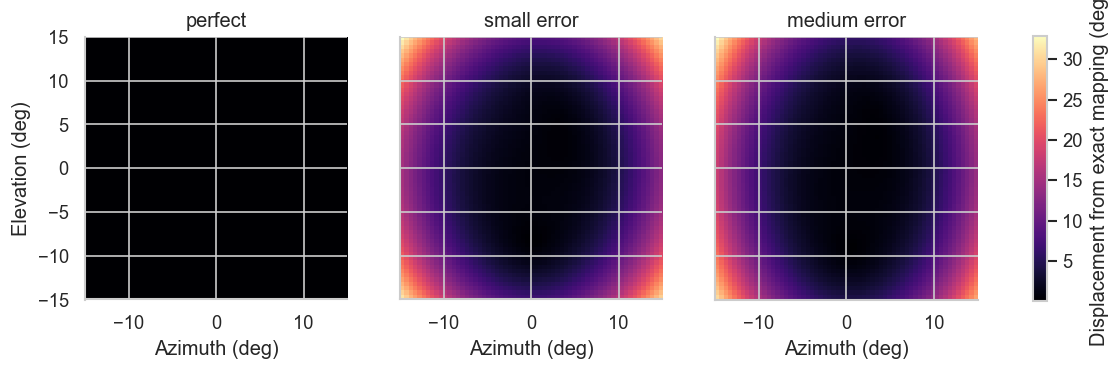

In [4]:
grid = np.linspace(-15, 15, 61)
aa, ee = np.meshgrid(grid, grid)
configs = {
    'perfect': load_config(ROOT / 'configs/mapping_error_none.yaml', debug=True),
    'small error': load_config(ROOT / 'configs/mapping_error_small.yaml', debug=True),
    'medium error': load_config(ROOT / 'configs/mapping_error_medium.yaml', debug=True),
}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
for ax, (name, local_cfg) in zip(axes, configs.items()):
    _, _, mag = mapping_error_field(aa, ee, local_cfg['mapping'])
    im = ax.imshow(mag, extent=[grid.min(), grid.max(), grid.min(), grid.max()], origin='lower', cmap='magma')
    ax.set_title(name)
    ax.set_xlabel('Azimuth (deg)')
axes[0].set_ylabel('Elevation (deg)')
fig.colorbar(im, ax=axes, label='Displacement from exact mapping (deg)', shrink=0.82)
plt.savefig(fig_dir / 'notebook01_mapping_validation.png', bbox_inches='tight')

## Example RFs

These are single Gabor RFs. That is a simplification for mouse L2/3, but it makes the phase, SF, RF size, and gaze-translation mechanisms transparent.

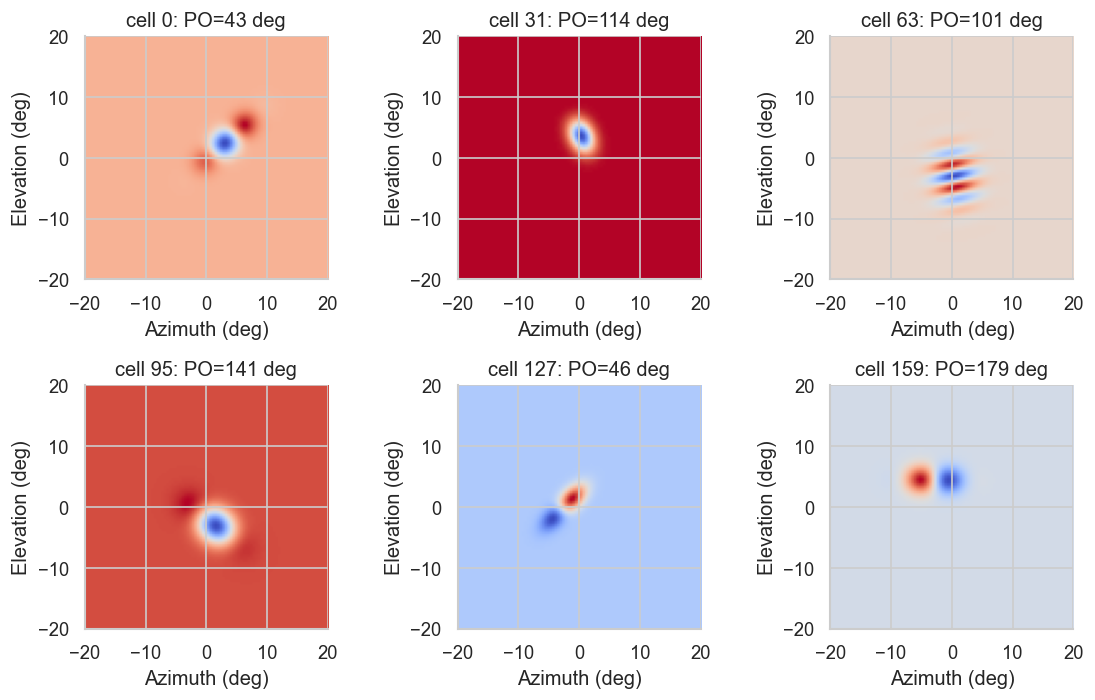

In [5]:
extent = cfg['stimuli']['natural_images']['extent_deg']
axis = np.linspace(-extent/2, extent/2, 96)
xx, yy = np.meshgrid(axis, axis)
fig, axes = plt.subplots(2, 3, figsize=(9.5, 6))
for ax, row_idx in zip(axes.ravel(), np.linspace(0, len(pop)-1, 6, dtype=int)):
    row = pop.iloc[row_idx]
    rf = gabor_kernel(xx, yy, center=(row.azimuth_deg, row.elevation_deg), theta_deg=row.theta0_deg, sf_cpd=row.f0_cpd, sigma_x_deg=row.sigma_x_deg, sigma_y_deg=row.sigma_y_deg, phase_rad=row.phase_rad, normalize=False)
    ax.imshow(rf, extent=[axis.min(), axis.max(), axis.min(), axis.max()], origin='lower', cmap='coolwarm')
    ax.set_title(f"cell {int(row.neuron_id)}: PO={row.theta0_deg:.0f} deg")
    ax.set_xlabel('Azimuth (deg)'); ax.set_ylabel('Elevation (deg)')
plt.tight_layout()
plt.savefig(fig_dir / 'notebook01_rf_examples.png', bbox_inches='tight')

## Takeaway

Before asking whether gaze changes PO estimates, verify this notebook first. If the RF sizes, SFs, jitter, or visual-field span are unrealistic for the experiment of interest, change the YAML configs before interpreting ΔPO or natural-image drift results.